In [1]:
import mlflow
from mlflow.models import infer_signature
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
import matplotlib.pyplot as plt

In [2]:
results = [] # to store time runtime of models

Logistic Regression

In [4]:
# Load preprocessed datasets
train_df = pd.read_csv("train_set_processed.csv")
val_df = pd.read_csv("validation_set_processed.csv")
test_df = pd.read_csv("test_set_processed.csv")

# Separate features and labels
X_train = train_df.drop("Response", axis=1)
y_train = train_df["Response"]

X_val = val_df.drop("Response", axis=1)
y_val = val_df["Response"]

X_test = test_df.drop("Response", axis=1)
y_test = test_df["Response"]

# Define categorical columns (excluding Region_Code and Policy_Sales_Channel for now)
categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

# Handle top 10 Policy_Sales_Channel
top_10_channels = X_train['Policy_Sales_Channel'].value_counts().nlargest(10).index
X_train['Policy_Sales_Channel'] = X_train['Policy_Sales_Channel'].apply(lambda x: x if x in top_10_channels else 'Other')
X_val['Policy_Sales_Channel'] = X_val['Policy_Sales_Channel'].apply(lambda x: x if x in top_10_channels else 'Other')
X_test['Policy_Sales_Channel'] = X_test['Policy_Sales_Channel'].apply(lambda x: x if x in top_10_channels else 'Other')

# Handle top 10 Region_Code
top_10_regions = X_train['Region_Code'].value_counts().nlargest(10).index
X_train['Region_Code'] = X_train['Region_Code'].apply(lambda x: x if x in top_10_regions else 'Other')
X_val['Region_Code'] = X_val['Region_Code'].apply(lambda x: x if x in top_10_regions else 'Other')
X_test['Region_Code'] = X_test['Region_Code'].apply(lambda x: x if x in top_10_regions else 'Other')

# Add to categorical columns
categorical_cols += ['Policy_Sales_Channel', 'Region_Code']

# One-Hot Encode categorical variables
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns across datasets
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

d:\MLOps\Lab 5\lab_5\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


Validation Performance:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79     33440
           1       0.27      0.91      0.42      4671

    accuracy                           0.69     38111
   macro avg       0.63      0.79      0.60     38111
weighted avg       0.90      0.69      0.74     38111

Test Performance:
              precision    recall  f1-score   support

           0     0.9828    0.6562    0.7870     66880
           1     0.2716    0.9179    0.4192      9342

    accuracy                         0.6883     76222
   macro avg     0.6272    0.7871    0.6031     76222
weighted avg     0.8957    0.6883    0.7419     76222



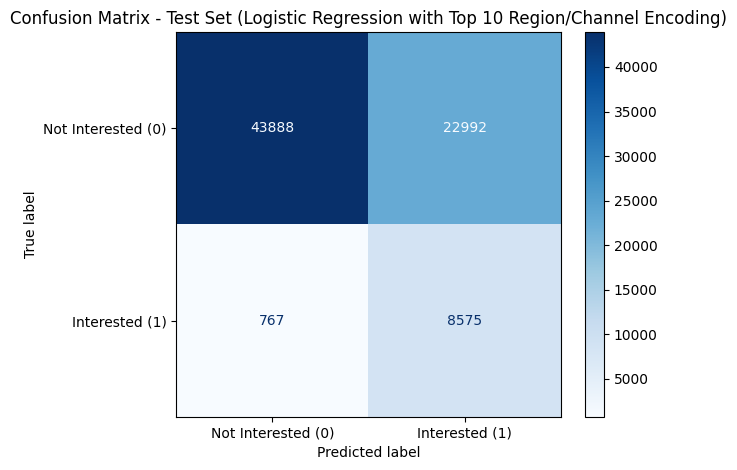

2025/11/17 19:03:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID: a9616e24daa84e4ea1ac01c5a93f0c9b


In [5]:
mlflow.set_experiment("insurance_response_logreg")  # name it however you like

with mlflow.start_run(run_name="logreg_top10_region_channel"):
    # Initialize and train the model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # -------------------------
    # Validation performance
    # -------------------------
    y_val_pred = model.predict(X_val)
    print("Validation Performance:")
    val_report = classification_report(y_val, y_val_pred)
    print(val_report)

    # Basic validation metrics to log
    mlflow.log_metric("val_accuracy", accuracy_score(y_val, y_val_pred))
    mlflow.log_metric("val_f1", f1_score(y_val, y_val_pred))
    mlflow.log_metric("val_precision", precision_score(y_val, y_val_pred))
    mlflow.log_metric("val_recall", recall_score(y_val, y_val_pred))

    # Save & log validation classification report as artifact
    with open("val_classification_report_logreg.txt", "w") as f:
        f.write(val_report)
    mlflow.log_artifact("val_classification_report_logreg.txt")

    # -------------------------
    # Test performance
    # -------------------------
    y_test_pred = model.predict(X_test)
    print("Test Performance:")
    test_report = classification_report(y_test, y_test_pred, digits=4)
    print(test_report)

    mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_test_pred))
    mlflow.log_metric("test_f1", f1_score(y_test, y_test_pred))
    mlflow.log_metric("test_precision", precision_score(y_test, y_test_pred))
    mlflow.log_metric("test_recall", recall_score(y_test, y_test_pred))

    with open("test_classification_report_logreg.txt", "w") as f:
        f.write(test_report)
    mlflow.log_artifact("test_classification_report_logreg.txt")

    # -------------------------
    # Confusion Matrix (Test)
    # -------------------------
    cm = confusion_matrix(y_test, y_test_pred)
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Interested (0)", "Interested (1)"],
    )
    disp.plot(cmap="Blues", ax=ax)
    plt.title(
        "Confusion Matrix - Test Set (Logistic Regression with Top 10 Region/Channel Encoding)"
    )
    plt.tight_layout()

    # Log confusion matrix figure
    mlflow.log_figure(fig, "confusion_matrix_logreg_test.png")
    plt.show()  # keeps your current behavior
    plt.close(fig)

    # -------------------------
    # Log model + params
    # -------------------------
    # All hyperparameters
    mlflow.log_params(model.get_params())

    # Log the trained model itself
    signature = infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_train.head(5),
    )

    print(f"Run ID: {mlflow.active_run().info.run_id}")


In [6]:
!mlflow ui --port 5001

^C


Lets add some regularization.

In [7]:
mlflow.set_experiment("insurance_response_logreg_tuning")

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42,
    )

    with mlflow.start_run(run_name=f"logreg_C_{C}"):
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        f1 = f1_score(y_val, y_val_pred)

        mlflow.log_param("C", C)
        mlflow.log_metric("val_f1", f1)

        # log the model for THIS C
        signature = infer_signature(X_val, y_val_pred)
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=X_val.head(5),
        )

        print(f"C={C}: val_f1={f1:.4f}")


2025/11/17 19:03:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


C=0.001: val_f1=0.4171


2025/11/17 19:03:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


C=0.01: val_f1=0.4182


2025/11/17 19:03:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

C=1: val_f1=0.4183


2025/11/17 19:03:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


C=10: val_f1=0.4182


2025/11/17 19:03:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


C=100: val_f1=0.4182


In [ ]:
import mlflow
from mlflow.models import infer_signature

mlflow.set_experiment("logreg_tuning")

for C in [0.001, 0.01, 0.1, 1, 10, 100]:

    with mlflow.start_run(run_name=f"logreg_C_{C}") as run:

        model = LogisticRegression(
            C=C,
            max_iter=1000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=42,
        )

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        # ---- log params ----
        mlflow.log_param("C", C)
        mlflow.log_param("solver", "lbfgs")
        mlflow.log_param("max_iter", 1000)
        mlflow.log_param("class_weight", "balanced")

        # ---- compute metrics ----
        val_f1 = f1_score(y_val, y_val_pred)
        mlflow.log_metric("val_f1", val_f1)

        # ---- log model ----
        signature = infer_signature(X_val, y_val_pred)
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            signature=signature,
            input_example=X_val.head(5),
        )

        print(f"C={C}, val_f1={val_f1:.4f}, run_id={run.info.run_id}")
